In [24]:
#exp1

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import label_binarize

# Load dataset (clean and correct)
iris = load_iris()

X = iris.data
y = iris.target

# Train-test split (IMPORTANT: stratify to avoid imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [20]:
n_estimators_list = [5, 10, 50, 100]
max_depth_list = [2, 3, 5, None]

results = []

for n in n_estimators_list:
    for depth in max_depth_list:
        model = RandomForestClassifier(
            n_estimators=n,
            max_depth=depth,
            random_state=42
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)

        results.append({
            "n_estimators": n,
            "max_depth": depth,
            "accuracy": acc
        })

# Convert to DataFrame
results_df = pd.DataFrame(results)
print(results_df)

    n_estimators  max_depth  accuracy
0              5        2.0  0.900000
1              5        3.0  0.933333
2              5        5.0  0.933333
3              5        NaN  0.933333
4             10        2.0  0.933333
5             10        3.0  0.966667
6             10        5.0  0.966667
7             10        NaN  0.966667
8             50        2.0  0.933333
9             50        3.0  0.966667
10            50        5.0  0.900000
11            50        NaN  0.900000
12           100        2.0  0.900000
13           100        3.0  0.966667
14           100        5.0  0.933333
15           100        NaN  0.900000


Accuracy: 0.9
Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]


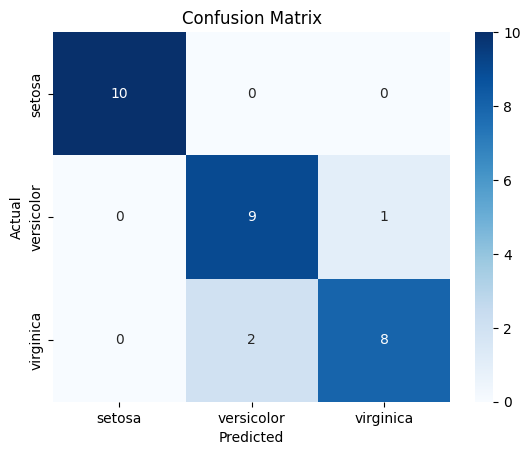

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [25]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred, target_names=iris.target_names))



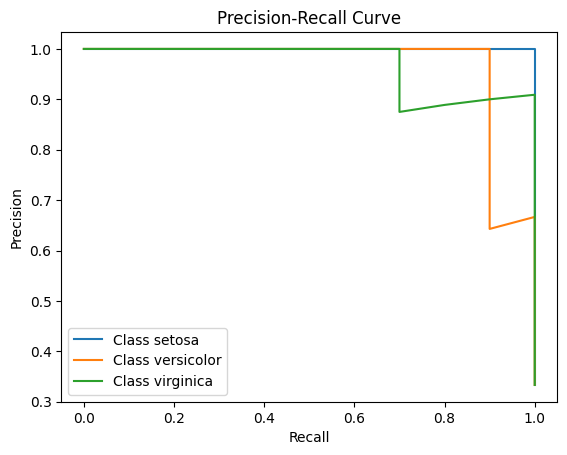

In [23]:
# Binarize labels
y_test_bin = label_binarize(y_test, classes=[0,1,2])

# Probabilities
y_prob = model.predict_proba(X_test)

# Plot PR curve for each class
for i in range(3):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_prob[:, i])

    plt.plot(recall, precision, label=f"Class {iris.target_names[i]}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [ ]:
#exp2

In [26]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Weak learner (decision stump)
base_estimator = DecisionTreeClassifier(max_depth=1)

# AdaBoost model
model = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

Accuracy: 0.9333333333333333
Confusion Matrix:
 [[10  0  0]
 [ 0  8  1]
 [ 0  1 10]]


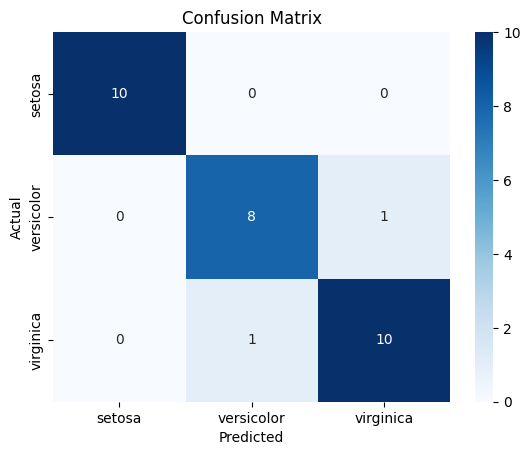

In [29]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [30]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.89      0.89      0.89         9
   virginica       0.91      0.91      0.91        11

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



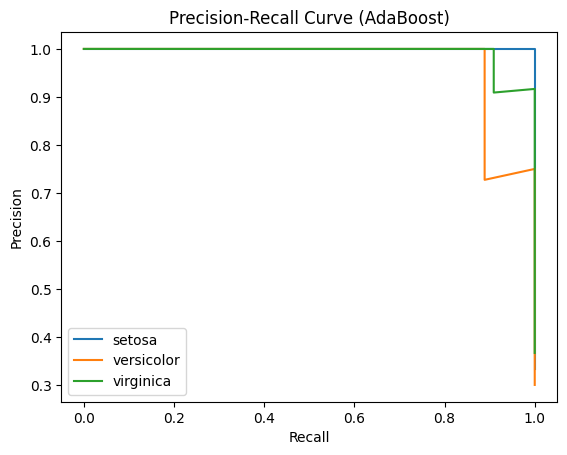

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Binarize labels
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_scores = model.predict_proba(X_test)

# Plot PR curve
for i in range(3):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_scores[:, i])
    plt.plot(recall, precision, label=iris.target_names[i])

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (AdaBoost)")
plt.legend()
plt.show()

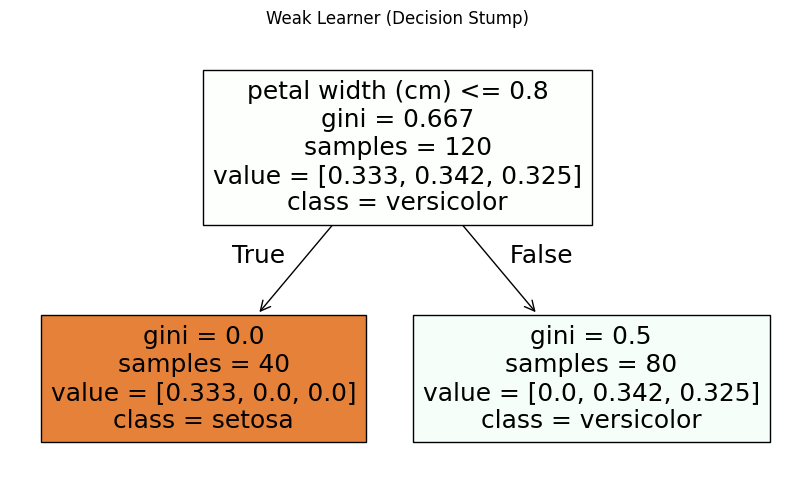

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plot_tree(model.estimators_[0], feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.title("Weak Learner (Decision Stump)")
plt.show()